In [1]:
import json
import yaml
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

raw_dir = Path("..") / config["paths"]["data_raw"]

batches = {}
for batch_file in sorted(raw_dir.glob("*.json")):
    batch_name = batch_file.stem
    with open(batch_file, "r", encoding="utf-8") as f:
        batches[batch_name] = json.load(f)

for name, papers in batches.items():
    print(f"{name} : {len(papers)} papers")



batch_01 : 500 papers
batch_02 : 500 papers
batch_03 : 500 papers
batch_04 : 500 papers


In [3]:
sample = batches["batch_01"][0]
for key, value in sample.items():
    print(f"{key}: {value[:120] if isinstance(value, str) else value}")

id: http://arxiv.org/abs/2401.00622v3
title: Federated Class-Incremental Learning with New-Class Augmented Self-Distillation
abstract: Federated Learning (FL) enables collaborative model training among participants while guaranteeing the privacy of raw da
published: 2024-01-01T00:54:02Z


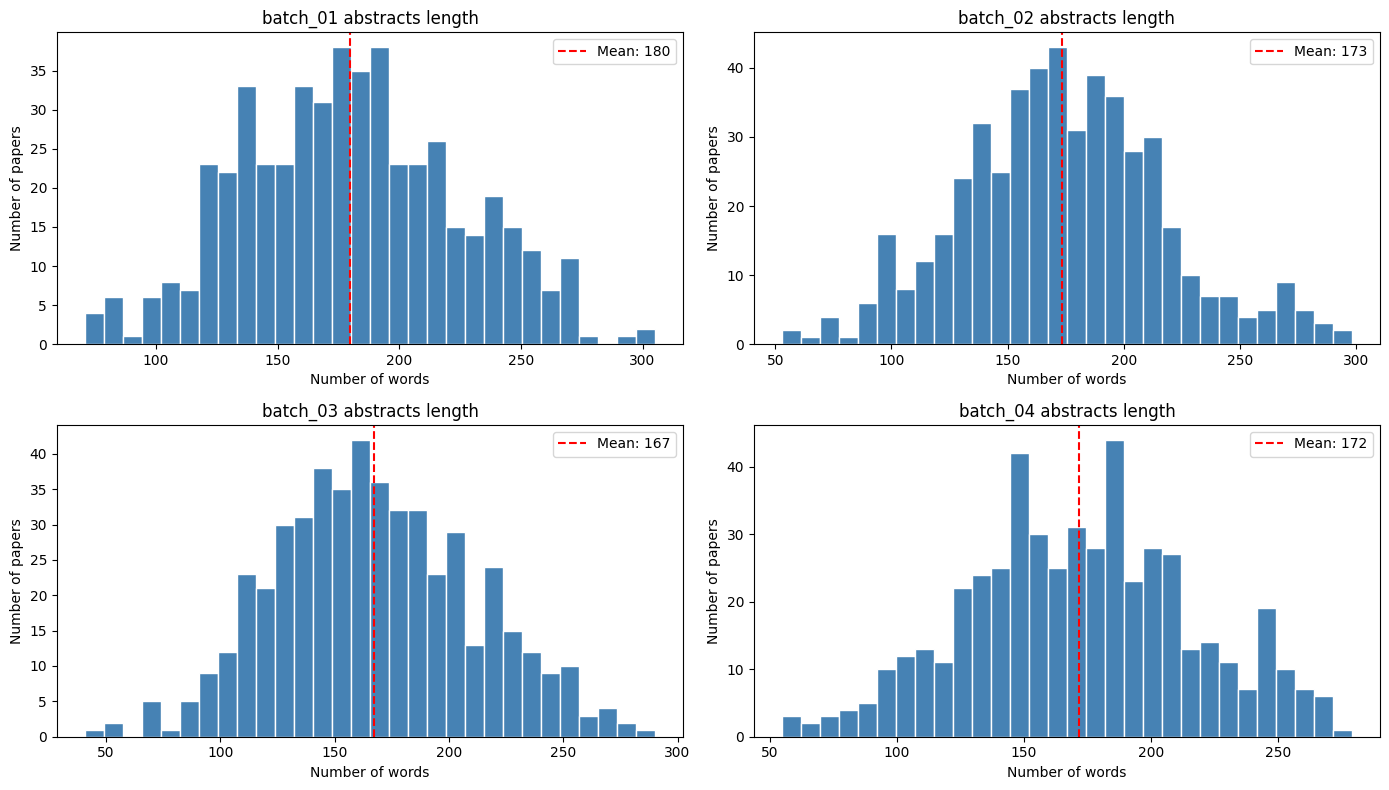

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, papers) in zip(axes.flat, batches.items()):
    lengths = [len(p["abstract"].split()) for p in papers]
    ax.hist(lengths, bins=30, color="steelblue", edgecolor="white")
    ax.set_title(f"{name} abstracts length")
    ax.set_xlabel("Number of words")
    ax.set_ylabel("Number of papers")
    mean_len = sum(lengths) / len(lengths)
    ax.axvline(mean_len, color="red", linestyle="--", label=f"Mean: {mean_len:.0f}")
    ax.legend()

plt.tight_layout()
plt.show()


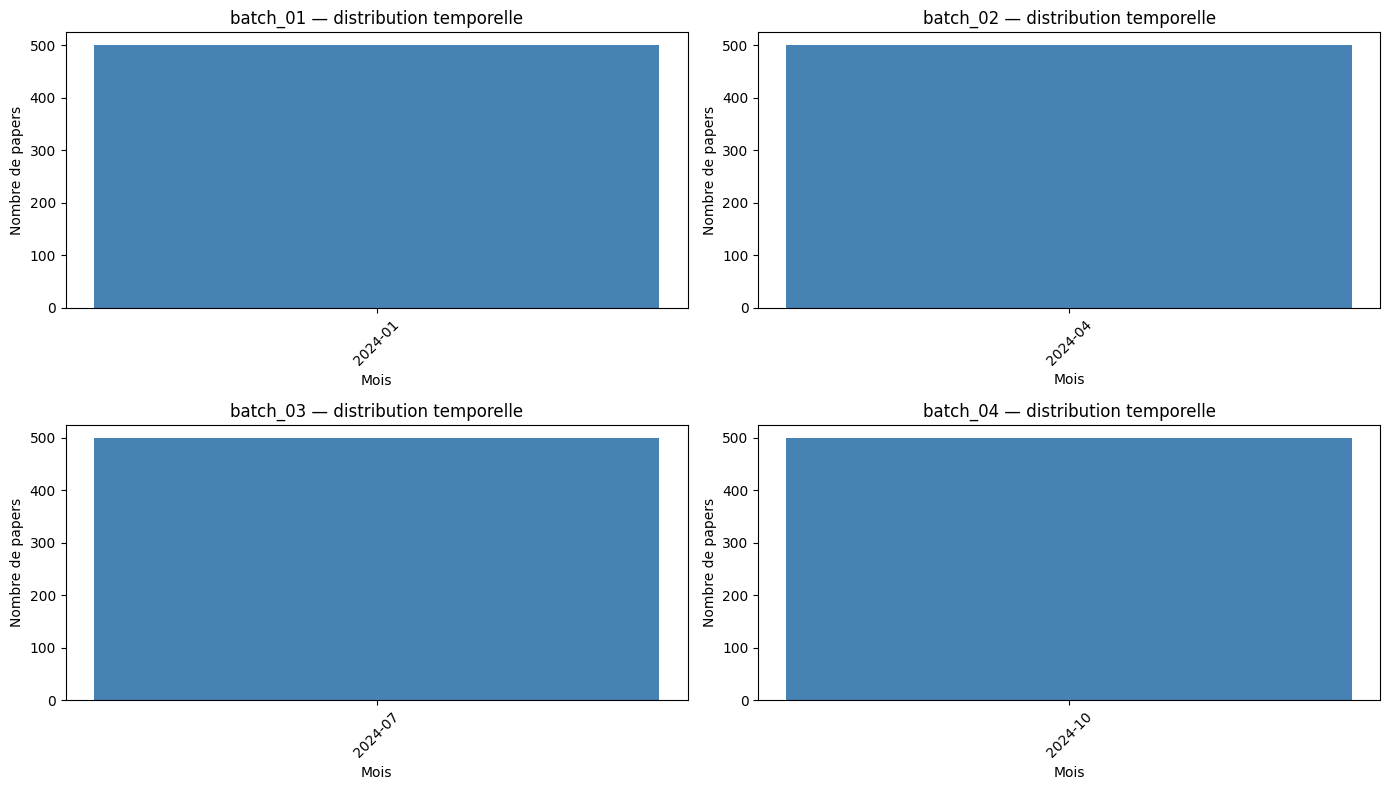

In [5]:
from collections import Counter

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (name, papers) in zip(axes.flat, batches.items()):
    months = [p["published"][:7] for p in papers]
    counts = Counter(months)
    sorted_months = sorted(counts.keys())
    ax.bar(sorted_months, [counts[m] for m in sorted_months], color="steelblue")
    ax.set_title(f"{name} — distribution temporelle")
    ax.set_xlabel("Mois")
    ax.set_ylabel("Nombre de papers")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


In [6]:
import random

for name, papers in batches.items():
    print(f"\n{name}")
    sample = random.sample(papers, 5)
    for p in sample:
        print(f"- {p['title']}")


batch_01
- Spikformer V2: Join the High Accuracy Club on ImageNet with an SNN Ticket
- GEN: A Practical Alternative to Graph Transformers for Long-Range Graph Modeling
- Siamese Residual Neural Network for Musical Shape Evaluation in Piano Performance Assessment
- MLLM-Protector: Ensuring MLLM's Safety without Hurting Performance
- Shared active subspace for multivariate vector-valued functions

batch_02
- Optical Text Recognition in Nepali and Bengali: A Transformer-based Approach
- FraGNNet: A Deep Probabilistic Model for Tandem Mass Spectrum Prediction
- DNN Memory Footprint Reduction via Post-Training Intra-Layer Multi-Precision Quantization
- Extracting Norms from Contracts Via ChatGPT: Opportunities and Challenges
- A neural network-based approach to hybrid systems identification for control

batch_03
- Foster Adaptivity and Balance in Learning with Noisy Labels
- A Practical Review of Mechanistic Interpretability for Transformer-Based Language Models
- Macroeconomic Forecasting

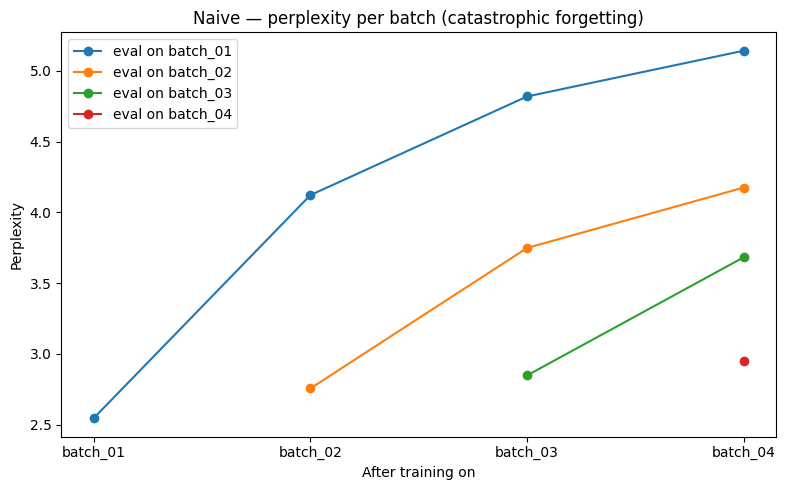

In [7]:
import json

with open("../results/naive_results.json") as f:
    results = json.load(f)

batches = list(results.keys())
fig, ax = plt.subplots(figsize=(8, 5))

for eval_batch in batches:
    x, y = [], []
    for train_batch in batches:
        if eval_batch in results[train_batch]:
            x.append(train_batch)
            y.append(results[train_batch][eval_batch])
    ax.plot(x, y, marker="o", label=f"eval on {eval_batch}")

ax.set_title("Naive — perplexity per batch (catastrophic forgetting)")
ax.set_xlabel("After training on")
ax.set_ylabel("Perplexity")
ax.legend()
plt.tight_layout()
plt.show()


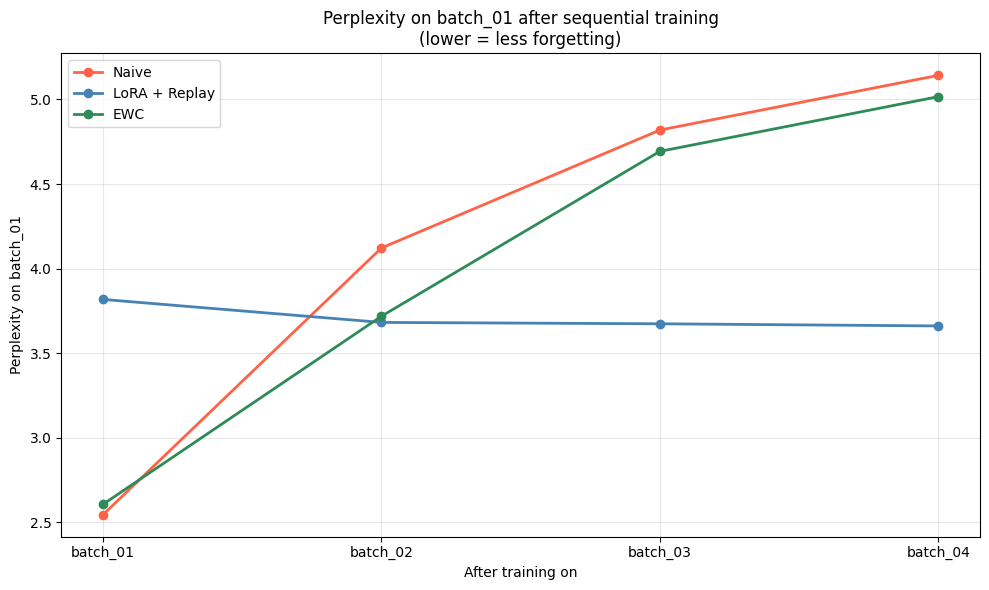

In [8]:
import json
import matplotlib.pyplot as plt

strategies = {
    "Naive": "../results/naive_results.json",
    "LoRA + Replay": "../results/lora_replay_results.json",
    "EWC": "../results/ewc_results.json",
}

colors = {"Naive": "tomato", "LoRA + Replay": "steelblue", "EWC": "seagreen"}

fig, ax = plt.subplots(figsize=(10, 6))

for strategy_name, path in strategies.items():
    with open(path) as f:
        results = json.load(f)

    train_batches = list(results.keys())
    perplexities = [results[b].get("batch_01") for b in train_batches]

    ax.plot(
        train_batches,
        perplexities,
        marker="o",
        label=strategy_name,
        color=colors[strategy_name],
        linewidth=2,
    )

ax.set_title("Perplexity on batch_01 after sequential training\n(lower = less forgetting)")
ax.set_xlabel("After training on")
ax.set_ylabel("Perplexity on batch_01")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


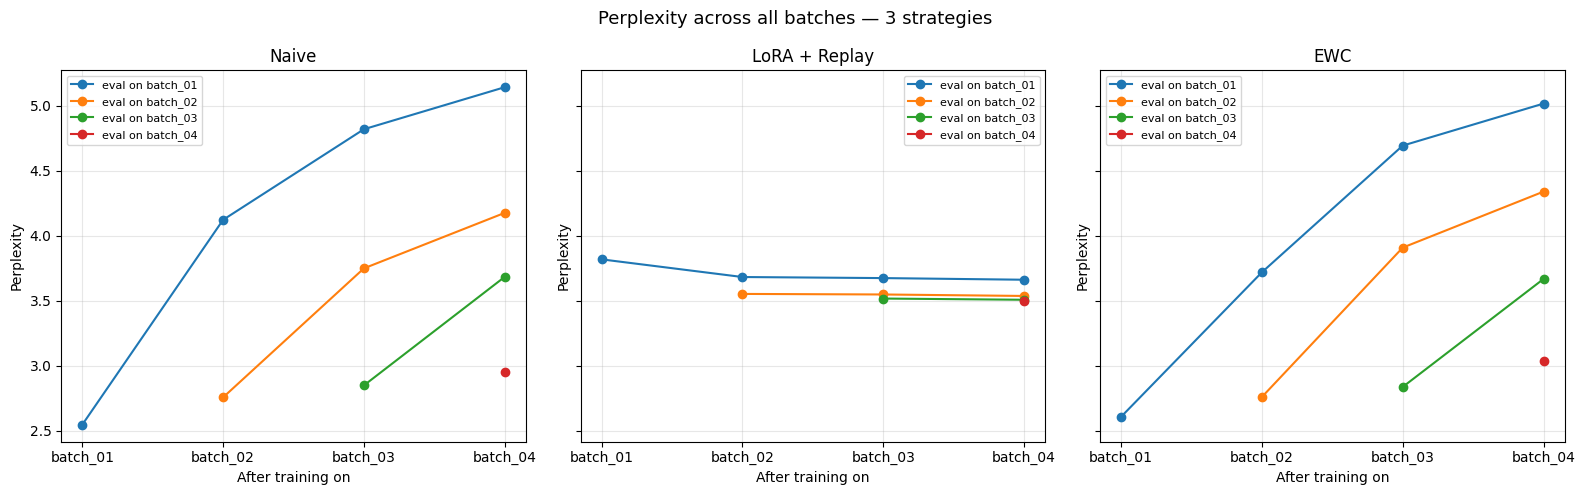

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, (strategy_name, path) in zip(axes, strategies.items()):
    with open(path) as f:
        results = json.load(f)

    train_batches = list(results.keys())

    for eval_batch in train_batches:
        x, y = [], []
        for train_batch in train_batches:
            if eval_batch in results[train_batch]:
                x.append(train_batch)
                y.append(results[train_batch][eval_batch])
        ax.plot(x, y, marker="o", label=f"eval on {eval_batch}")

    ax.set_title(strategy_name)
    ax.set_xlabel("After training on")
    ax.set_ylabel("Perplexity")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Perplexity across all batches — 3 strategies", fontsize=13)
plt.tight_layout()
plt.show()
